<a href="https://colab.research.google.com/github/Neu-Utkarsh/Practice-PyTorch/blob/main/MyTorch_00/04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch


In [2]:
learning_rate = 0.1
x = torch.tensor(5.0, requires_grad=True)
for iteration in range(100):
  f = x**2
  f.backward()
  with torch.no_grad():
    x-= learning_rate * x.grad

  x.grad.zero_()

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state= 42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)


In [4]:
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)

means = X_train.mean(dim=0, keepdims=True)
stds = X_train.std(dim=0, keepdims=True)

X_train = (X_train - means)/stds
X_valid = (X_valid - means)/stds
X_test = (X_test - means)/stds

In [5]:
y_train = torch.FloatTensor(y_train).reshape(-1, 1)
y_valid = torch.FloatTensor(y_valid).reshape(-1, 1)
y_test = torch.FloatTensor(y_test).reshape(-1, 1)

In [6]:
torch.manual_seed(42)
n_features = X_train.shape[1]  # there are 8 input features
w = torch.randn((n_features, 1), requires_grad=True)
b = torch.tensor(0., requires_grad=True)

In [7]:
leanring_rate = 0.4
n_epochs =20
for epoch in range(n_epochs):
  y_pred = X_train @ w + b
  loss = ((y_pred-y_train)**2).mean()
  loss.backward()
  with torch.no_grad() :
    b -= learning_rate *b.grad
    w -= learning_rate * w.grad
    b.grad.zero_()
    w.grad.zero_()
  print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item()}")

Epoch 1/20, Loss: 16.158456802368164
Epoch 2/20, Loss: 7.856922149658203
Epoch 3/20, Loss: 4.358489513397217
Epoch 4/20, Loss: 2.7617008686065674
Epoch 5/20, Loss: 1.9637987613677979
Epoch 6/20, Loss: 1.528319001197815
Epoch 7/20, Loss: 1.2721476554870605
Epoch 8/20, Loss: 1.11244535446167
Epoch 9/20, Loss: 1.0084103345870972
Epoch 10/20, Loss: 0.9382220506668091
Epoch 11/20, Loss: 0.8893815279006958
Epoch 12/20, Loss: 0.8543529510498047
Epoch 13/20, Loss: 0.8284299969673157
Epoch 14/20, Loss: 0.8086025714874268
Epoch 15/20, Loss: 0.7929145693778992
Epoch 16/20, Loss: 0.7800787687301636
Epoch 17/20, Loss: 0.769240140914917
Epoch 18/20, Loss: 0.7598254084587097
Epoch 19/20, Loss: 0.7514469027519226
Epoch 20/20, Loss: 0.7438402771949768


In [8]:
X_new = X_test[:3]  # pretend these are new instances
with torch.no_grad():
  y_pred = X_new @ w + b  # use the trained parameters to make predictions

y_pred

tensor([[1.1464],
        [1.4479],
        [2.2722]])

In [9]:
import torch.nn as nn
torch.manual_seed(42)
model = nn.Linear(in_features = n_features, out_features=1)

In [10]:
model.bias

Parameter containing:
tensor([0.3117], requires_grad=True)

In [11]:
model.weight

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)

In [12]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)
Parameter containing:
tensor([0.3117], requires_grad=True)


In [13]:
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
mse = nn.MSELoss()

In [14]:
def train_bgd(model, optimizer, criterion, X_train, y_train, n_epochs):
  for epoch in range(n_epochs):
    y_pred = model(X_train)
    loss = criterion(y_pred,y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    if epoch % 2 == 0:
      print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item()}")

In [15]:
train_bgd(model,optimizer,mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 4.3378496170043945
Epoch 3/20, Loss: 2.1127142906188965
Epoch 5/20, Loss: 1.2240110635757446
Epoch 7/20, Loss: 0.8627150058746338
Epoch 9/20, Loss: 0.7132189869880676
Epoch 11/20, Loss: 0.6495375633239746
Epoch 13/20, Loss: 0.6208688616752625
Epoch 15/20, Loss: 0.6066169738769531
Epoch 17/20, Loss: 0.5983984470367432
Epoch 19/20, Loss: 0.592787504196167


In [16]:
X_new = X_test[:3]
with torch.no_grad() :
  y_pred = model(X_new)
y_pred

tensor([[0.9308],
        [1.5995],
        [2.4999]])

In [17]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features,50),
    nn.ReLU(),
    nn.Linear(50,40),
    nn.ReLU(),
    nn.Linear(40,1)
)

In [18]:
learning_rate= 0.1
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
mse = nn.MSELoss()
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 5.045480251312256
Epoch 3/20, Loss: 1.0039883852005005
Epoch 5/20, Loss: 0.7740675210952759
Epoch 7/20, Loss: 0.6893726587295532
Epoch 9/20, Loss: 0.6507738828659058
Epoch 11/20, Loss: 0.6281993389129639
Epoch 13/20, Loss: 0.6113173365592957
Epoch 15/20, Loss: 0.5968307852745056
Epoch 17/20, Loss: 0.5836468935012817
Epoch 19/20, Loss: 0.5713554620742798


In [19]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size = 32, shuffle=True)


In [20]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [21]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 1)
)

model = model.to(device)

learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()

In [22]:
def train(model,optimizer,criterion,train_dataloader,n_epochs):
  model.train()
  for epoch in range(n_epochs):
    total_loss = 0
    for X_batch,y_batch in train_dataloader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred,y_batch)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    mean_loss = total_loss / len(train_dataloader)
    if epoch %2 != 0:
      print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_dataloader)}")

In [23]:
train(model, optimizer, mse, train_dataloader, n_epochs)

Epoch 2/20, Loss: 0.40455259957425194
Epoch 4/20, Loss: 0.36294833915539026
Epoch 6/20, Loss: 0.35195001168561374
Epoch 8/20, Loss: 0.3426984136426416
Epoch 10/20, Loss: 0.33776922253045166
Epoch 12/20, Loss: 0.326692136810174
Epoch 14/20, Loss: 0.3220852158614755
Epoch 16/20, Loss: 0.31485551105139997
Epoch 18/20, Loss: 0.3110704014370264
Epoch 20/20, Loss: 0.30719890915493664


## Evaluating

In [24]:
def evaluate(model, data_loader, metric_fn, aggregate_fn = torch.mean) :
  model.eval()
  metrics = []
  with torch.no_grad() :
    for X_batch,y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric = metric_fn(y_pred,y_batch)
      metrics.append(metric)
  return aggregate_fn(torch.stack(metrics))

In [25]:
valid_dataset = TensorDataset(X_valid,y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32)
valid_mse = evaluate(model, valid_loader, mse)
valid_mse

tensor(0.4080, device='cuda:0')

In [26]:
evaluate(model, valid_loader, mse,
         aggregate_fn=lambda metrics: torch.sqrt(torch.mean(metrics)))

tensor(0.6388, device='cuda:0')

In [27]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 38.5 MB/s eta 0:00:00


In [28]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
  model.eval()
  metric.reset()
  with torch.no_grad() :
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric.update(y_pred,y_batch)
  return metric.compute()

In [29]:
rsme = torchmetrics.MeanSquaredError(squared=False)
evaluate_tm(model, valid_loader, rsme)

RuntimeError: Encountered different devices in metric calculation (see stacktrace for details). This could be due to the metric class not being on the same device as input. Instead of `metric=MeanSquaredError(...)` try to do `metric=MeanSquaredError(...).to(device)` where device corresponds to the device of the input.

In [30]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history


## Learning Non Sequential Models

In [31]:
class WideAndDeep(nn.Module):
  def __init__(self,n_features):
    super().__init__()
    self.deep_stack = nn.Sequential(
        nn.Linear(n_features,50), nn.ReLU(),
        nn.Linear(50,40), nn.ReLU(),
    )
    self.output_layer = nn.Linear(40+n_features,1)

  def forward(self,X):
    deep_output = self.deep_stack(X)
    wide_and_deep = torch.concat([X, deep_output], dim=1)
    return self.output_layer(wide_and_deep)


In [32]:
torch.manual_seed(42)
model = WideAndDeep(n_features).to(device)
learning_rate = 0.002

In [33]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train2(model, optimizer, mse, rmse, train_dataloader, valid_loader,
                 n_epochs=20)

Epoch 1/20, train loss: 1.4093, train metric: 1.1873, valid metric: 0.8794
Epoch 2/20, train loss: 0.6105, train metric: 0.7815, valid metric: 0.8410
Epoch 3/20, train loss: 0.5624, train metric: 0.7500, valid metric: 0.7263
Epoch 4/20, train loss: 0.5267, train metric: 0.7256, valid metric: 0.7730
Epoch 5/20, train loss: 0.5050, train metric: 0.7105, valid metric: 0.7300
Epoch 6/20, train loss: 0.4800, train metric: 0.6929, valid metric: 0.6787
Epoch 7/20, train loss: 0.4648, train metric: 0.6819, valid metric: 0.6950
Epoch 8/20, train loss: 0.4505, train metric: 0.6711, valid metric: 0.6437
Epoch 9/20, train loss: 0.4397, train metric: 0.6631, valid metric: 0.7005
Epoch 10/20, train loss: 0.4309, train metric: 0.6564, valid metric: 0.6289
Epoch 11/20, train loss: 0.4227, train metric: 0.6502, valid metric: 0.6604
Epoch 12/20, train loss: 0.4161, train metric: 0.6451, valid metric: 0.6223
Epoch 13/20, train loss: 0.4097, train metric: 0.6402, valid metric: 0.6729
Epoch 14/20, train lo

In [34]:
class WideAndDeepV2(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)

    def forward(self, X):
        X_wide = X[:, :5]
        X_deep = X[:, 2:]
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

In [35]:
class WideAndDeepV3(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)

    def forward(self, X_wide, X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

In [36]:
train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True)

valid_data_wd = TensorDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
valid_loader_wd = DataLoader(valid_data_wd, batch_size=32)

test_data_wd = TensorDataset(X_test[:, :5], X_test[:, 2:], y_test)
test_loader_wd = DataLoader(test_data_wd, batch_size=32)

In [37]:
def evaluate_multi_in(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch_wide, X_batch_deep, y_batch in data_loader:
            X_batch_wide = X_batch_wide.to(device)
            X_batch_deep = X_batch_deep.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch_wide, X_batch_deep)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

def train_multi_in(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for *X_batch_inputs, y_batch in train_loader:
            model.train()
            X_batch_inputs = [X.to(device) for X in X_batch_inputs]
            y_batch = y_batch.to(device)
            y_pred = model(*X_batch_inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_in(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_multi_in(model, optimizer, mse, rmse, train_loader_wd,
                         valid_loader_wd, n_epochs)

Epoch 1/20, train loss: 0.8366, train metric: 0.9148, valid metric: 0.6892
Epoch 2/20, train loss: 0.4627, train metric: 0.6803, valid metric: 0.6455
Epoch 3/20, train loss: 0.4319, train metric: 0.6572, valid metric: 0.6374
Epoch 4/20, train loss: 0.4259, train metric: 0.6525, valid metric: 0.6512
Epoch 5/20, train loss: 0.4120, train metric: 0.6420, valid metric: 0.6305
Epoch 6/20, train loss: 0.4040, train metric: 0.6356, valid metric: 0.6287
Epoch 7/20, train loss: 0.4005, train metric: 0.6330, valid metric: 0.6252
Epoch 8/20, train loss: 0.3976, train metric: 0.6306, valid metric: 0.6158
Epoch 9/20, train loss: 0.3883, train metric: 0.6230, valid metric: 0.7407
Epoch 10/20, train loss: 0.3866, train metric: 0.6218, valid metric: 0.6063
Epoch 11/20, train loss: 0.3752, train metric: 0.6125, valid metric: 0.5974
Epoch 12/20, train loss: 0.3704, train metric: 0.6087, valid metric: 0.5888
Epoch 13/20, train loss: 0.3677, train metric: 0.6063, valid metric: 0.5981
Epoch 14/20, train lo

In [38]:
class WideAndDeepDataset(torch.utils.data.Dataset):
    def __init__(self, X_wide, X_deep, y):
        self.X_wide = X_wide
        self.X_deep = X_deep
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        input_dict = {"X_wide": self.X_wide[idx], "X_deep": self.X_deep[idx]}
        return input_dict, self.y[idx]

In [39]:
torch.manual_seed(42)
train_data_named = WideAndDeepDataset(
    X_wide=X_train[:, :5], X_deep=X_train[:, 2:], y=y_train)
train_loader_named = DataLoader(train_data_named, batch_size=32, shuffle=True)
valid_data_named = WideAndDeepDataset(
    X_wide=X_valid[:, :5], X_deep=X_valid[:, 2:], y=y_valid)
valid_loader_named = DataLoader(valid_data_named, batch_size=32)
test_data_named = WideAndDeepDataset(
    X_wide=X_test[:, :5], X_deep=X_test[:, 2:], y=y_test)
test_loader_named = DataLoader(test_data_named, batch_size=32)

In [40]:
def evaluate_named(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred = model(X_wide=inputs["X_wide"], X_deep=inputs["X_deep"])
            metric.update(y_pred, y_batch)
    return metric.compute()  # compute the final result at the end

def train_named(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for inputs, y_batch in train_loader:
            model.train()
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred = model(**inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_named(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_named(model, optimizer, mse, rmse, train_loader_named,
                      valid_loader_named, n_epochs)

Epoch 1/20, train loss: 0.8366, train metric: 0.9148, valid metric: 0.6892
Epoch 2/20, train loss: 0.4627, train metric: 0.6803, valid metric: 0.6455
Epoch 3/20, train loss: 0.4319, train metric: 0.6572, valid metric: 0.6374
Epoch 4/20, train loss: 0.4259, train metric: 0.6525, valid metric: 0.6512
Epoch 5/20, train loss: 0.4120, train metric: 0.6420, valid metric: 0.6305
Epoch 6/20, train loss: 0.4040, train metric: 0.6356, valid metric: 0.6287
Epoch 7/20, train loss: 0.4005, train metric: 0.6330, valid metric: 0.6252
Epoch 8/20, train loss: 0.3976, train metric: 0.6306, valid metric: 0.6158
Epoch 9/20, train loss: 0.3883, train metric: 0.6230, valid metric: 0.7407
Epoch 10/20, train loss: 0.3866, train metric: 0.6218, valid metric: 0.6063
Epoch 11/20, train loss: 0.3752, train metric: 0.6125, valid metric: 0.5974
Epoch 12/20, train loss: 0.3704, train metric: 0.6087, valid metric: 0.5888
Epoch 13/20, train loss: 0.3677, train metric: 0.6063, valid metric: 0.5981
Epoch 14/20, train lo

In [41]:
class WideAndDeepV4(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)
        self.aux_output_layer = nn.Linear(30, 1)

    def forward(self, X_wide, X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        main_output = self.output_layer(wide_and_deep)
        aux_output = self.aux_output_layer(deep_output)
        return main_output, aux_output

In [42]:
import torchmetrics

def evaluate_multi_out(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, _ = model(**inputs)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train_multi_out(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for inputs, y_batch in train_loader:
            model.train()
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, y_pred_aux = model(**inputs)
            main_loss = criterion(y_pred, y_batch)
            aux_loss = criterion(y_pred_aux, y_batch)
            loss = 0.8 * main_loss + 0.2 * aux_loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_out(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV4(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_multi_out(model, optimizer, mse, rmse, train_loader_named,
                          valid_loader_named, n_epochs)

Epoch 1/20, train loss: 1.0693, train metric: 0.9506, valid metric: 0.7085
Epoch 2/20, train loss: 0.5817, train metric: 0.6946, valid metric: 0.6607
Epoch 3/20, train loss: 0.5010, train metric: 0.6581, valid metric: 0.6425
Epoch 4/20, train loss: 0.4690, train metric: 0.6497, valid metric: 0.6654
Epoch 5/20, train loss: 0.4503, train metric: 0.6420, valid metric: 0.6338
Epoch 6/20, train loss: 0.4387, train metric: 0.6373, valid metric: 0.6563
Epoch 7/20, train loss: 0.4315, train metric: 0.6330, valid metric: 0.6193
Epoch 8/20, train loss: 0.4249, train metric: 0.6302, valid metric: 0.6167
Epoch 9/20, train loss: 0.4116, train metric: 0.6202, valid metric: 0.6450
Epoch 10/20, train loss: 0.4085, train metric: 0.6198, valid metric: 0.5938
Epoch 11/20, train loss: 0.4073, train metric: 0.6197, valid metric: 0.5959
Epoch 12/20, train loss: 0.3914, train metric: 0.6078, valid metric: 0.6073
Epoch 13/20, train loss: 0.3847, train metric: 0.6033, valid metric: 0.5815
Epoch 14/20, train lo

## Building Image Classifier

In [43]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale = True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root = 'datasets', train= True, download=True, transform=toTensor
)
test_data = torchvision.datasets.FashionMNIST(
    root = 'datasets', train= False, download=True, transform=toTensor
)

train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000]
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 116MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.70MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 61.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.6MB/s]


In [44]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [45]:
X_sample, y_sample = train_data[0]

In [46]:
X_sample.shape

torch.Size([1, 28, 28])

In [47]:
train_and_valid_data.classes[y_sample]

'Sandal'

In [48]:
# Classifier
class ImageClassifier(nn.Module):
  def __init__(self,n_inputs, n_hidden1,n_hidden2,n_classes):
    super().__init__()
    self.mlp = nn.Sequential(
        nn.Flatten(),
        nn.Linear(n_inputs, n_hidden1),
        nn.ReLU(),
        nn.Linear(n_hidden1, n_hidden2),
        nn.ReLU(),
        nn.Linear(n_hidden2, n_classes)
    )

  def forward(self,X):
    return self.mlp(X)

In [51]:
model = ImageClassifier(28*28,300,100,10).to(device)
xentropy = nn.CrossEntropyLoss()


In [52]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

_ = train2(model,optimizer,xentropy, accuracy, train_loader, valid_loader, n_epochs=10)

Epoch 1/10, train loss: 0.5972, train metric: 0.7815, valid metric: 0.8460
Epoch 2/10, train loss: 0.4054, train metric: 0.8517, valid metric: 0.8628
Epoch 3/10, train loss: 0.3625, train metric: 0.8644, valid metric: 0.8634
Epoch 4/10, train loss: 0.3339, train metric: 0.8761, valid metric: 0.8744
Epoch 5/10, train loss: 0.3131, train metric: 0.8827, valid metric: 0.8738
Epoch 6/10, train loss: 0.2978, train metric: 0.8878, valid metric: 0.8830
Epoch 7/10, train loss: 0.2825, train metric: 0.8933, valid metric: 0.8854
Epoch 8/10, train loss: 0.2722, train metric: 0.8986, valid metric: 0.8866
Epoch 9/10, train loss: 0.2590, train metric: 0.9033, valid metric: 0.8920
Epoch 10/10, train loss: 0.2521, train metric: 0.9051, valid metric: 0.8848


In [53]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)  # index of the largest logit
y_pred

tensor([1, 9, 3], device='cuda:0')

In [54]:
[train_and_valid_data.classes[index] for index in y_pred]

['Trouser', 'Ankle boot', 'Dress']

In [55]:
y_new[:3]

tensor([1, 9, 3])

## Using OPtuna for FineTuning

In [57]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 19.6 MB/s eta 0:00:00


In [58]:
import optuna

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden,
                            n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    history = train2(model, optimizer, xentropy, accuracy, train_loader,
                     valid_loader, n_epochs=10)
    validation_accuracy = max(history["valid_metrics"])
    return validation_accuracy

In [59]:
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=5)

[I 2025-10-17 20:01:00,492] A new study created in memory with name: no-name-6caf3aeb-1398-484f-82de-a35ad603cf70


Epoch 1/10, train loss: 2.2688, train metric: 0.1759, valid metric: 0.2542
Epoch 2/10, train loss: 2.1995, train metric: 0.2601, valid metric: 0.2904
Epoch 3/10, train loss: 2.0999, train metric: 0.3270, valid metric: 0.3902
Epoch 4/10, train loss: 1.9528, train metric: 0.4638, valid metric: 0.5274
Epoch 5/10, train loss: 1.7609, train metric: 0.5670, valid metric: 0.6054
Epoch 6/10, train loss: 1.5623, train metric: 0.6154, valid metric: 0.6170
Epoch 7/10, train loss: 1.3933, train metric: 0.6197, valid metric: 0.6290
Epoch 8/10, train loss: 1.2609, train metric: 0.6304, valid metric: 0.6448
Epoch 9/10, train loss: 1.1588, train metric: 0.6427, valid metric: 0.6446


[I 2025-10-17 20:03:37,050] Trial 0 finished with value: 0.6600000262260437 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.6600000262260437.


Epoch 10/10, train loss: 1.0788, train metric: 0.6518, valid metric: 0.6600
Epoch 1/10, train loss: 1.1622, train metric: 0.6206, valid metric: 0.7530
Epoch 2/10, train loss: 0.6225, train metric: 0.7820, valid metric: 0.8074
Epoch 3/10, train loss: 0.5279, train metric: 0.8155, valid metric: 0.8198
Epoch 4/10, train loss: 0.4873, train metric: 0.8284, valid metric: 0.8322
Epoch 5/10, train loss: 0.4597, train metric: 0.8389, valid metric: 0.8396
Epoch 6/10, train loss: 0.4421, train metric: 0.8456, valid metric: 0.8422
Epoch 7/10, train loss: 0.4267, train metric: 0.8512, valid metric: 0.8506
Epoch 8/10, train loss: 0.4125, train metric: 0.8555, valid metric: 0.8560
Epoch 9/10, train loss: 0.4015, train metric: 0.8590, valid metric: 0.8516


[I 2025-10-17 20:06:11,097] Trial 1 finished with value: 0.8560000061988831 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.8560000061988831.


...

Epoch 10/10, train loss: 2.2563, train metric: 0.3096, valid metric: 0.3222
Epoch 1/10, train loss: 2.3014, train metric: 0.1124, valid metric: 0.1136
Epoch 2/10, train loss: 2.2978, train metric: 0.1151, valid metric: 0.1160
Epoch 3/10, train loss: 2.2942, train metric: 0.1181, valid metric: 0.1192
Epoch 4/10, train loss: 2.2907, train metric: 0.1215, valid metric: 0.1236
Epoch 5/10, train loss: 2.2872, train metric: 0.1258, valid metric: 0.1284
Epoch 6/10, train loss: 2.2837, train metric: 0.1302, valid metric: 0.1322
Epoch 7/10, train loss: 2.2802, train metric: 0.1355, valid metric: 0.1362
Epoch 8/10, train loss: 2.2768, train metric: 0.1395, valid metric: 0.1408
Epoch 9/10, train loss: 2.2733, train metric: 0.1441, valid metric: 0.1452


[I 2025-10-17 20:11:03,747] Trial 3 finished with value: 0.15080000460147858 and parameters: {'learning_rate': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.8560000061988831.


Epoch 10/10, train loss: 2.2699, train metric: 0.1482, valid metric: 0.1508
Epoch 1/10, train loss: 1.8124, train metric: 0.5066, valid metric: 0.6116
Epoch 2/10, train loss: 0.9805, train metric: 0.6560, valid metric: 0.6866
Epoch 3/10, train loss: 0.7711, train metric: 0.7133, valid metric: 0.7370
Epoch 4/10, train loss: 0.6813, train metric: 0.7552, valid metric: 0.7702
Epoch 5/10, train loss: 0.6216, train metric: 0.7827, valid metric: 0.7938
Epoch 6/10, train loss: 0.5772, train metric: 0.8011, valid metric: 0.8042
Epoch 7/10, train loss: 0.5457, train metric: 0.8121, valid metric: 0.8170
Epoch 8/10, train loss: 0.5219, train metric: 0.8193, valid metric: 0.8170
Epoch 9/10, train loss: 0.5034, train metric: 0.8246, valid metric: 0.8244


[I 2025-10-17 20:13:26,290] Trial 4 finished with value: 0.8252000212669373 and parameters: {'learning_rate': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.8560000061988831.


Epoch 10/10, train loss: 0.4891, train metric: 0.8298, valid metric: 0.8252


In [60]:
study.best_params

{'learning_rate': 0.008471801418819975, 'n_hidden': 188}

In [61]:
study.best_value

0.8560000061988831

In [62]:
torch.save(model, "my_fashion_mnist.pt")

In [63]:
loaded_model = torch.load("my_fashion_mnist.pt", weights_only=False)

In [64]:
loaded_model.eval()
y_pred_logits = loaded_model(X_new)

In [65]:
torch.save(model.state_dict(), "my_fashion_mnist_weights.pt")

In [66]:
type(model.state_dict())

collections.OrderedDict

In [67]:
new_model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                            n_classes=10)
loaded_weights = torch.load("my_fashion_mnist_weights.pt", weights_only=True)
new_model.load_state_dict(loaded_weights)
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [68]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {
        "n_inputs": 1 * 28 * 28,
        "n_hidden1": 300,
        "n_hidden2": 100,
        "n_classes": 10,
    }
}
torch.save(model_data, "my_fashion_mnist_model.pt")

In [69]:
loaded_data = torch.load("my_fashion_mnist_model.pt", weights_only=True)
new_model = ImageClassifier(**loaded_data["model_hyperparameters"])
new_model.load_state_dict(loaded_data["model_state_dict"])
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

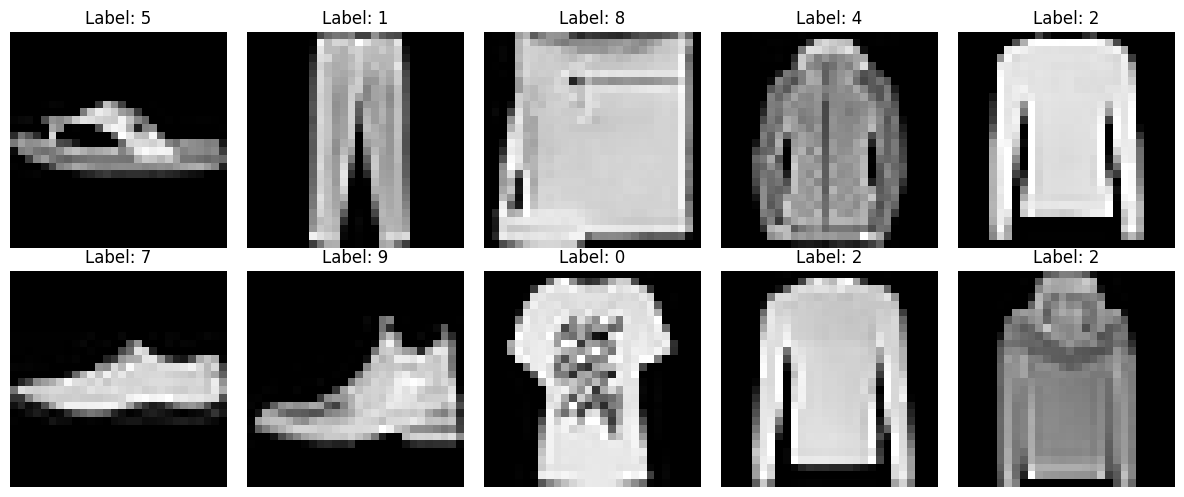

In [72]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    img, lbl = train_data[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {lbl}")
    ax.axis("off")
plt.tight_layout()
plt.show()
